# A* Pathfinding for Multi-Agent Warehouse Robots

This notebook implements A* based algorithms for solving the Multi-Agent Path Finding (MAPF) problem in a warehouse environment.

## Overview
- **Node Class**: Represents a node in the search tree
- **GridEnvironment**: 2D grid-based warehouse environment
- **Robot Class**: Represents a single robot
- **AutomatedWarehouseRobotControllerProblem**: Encapsulates the MAPF problem
- **A_Star**: Base A* class with conflict checking
- **IndependentAStar**: Each robot finds path independently (no coordination)
- **CooperativeAStar**: Robots coordinate using reservation tables
- **ConflictDetector**: Detects vertex and swap conflicts
- **MAPFBenchmark**: Benchmarking and evaluation
- **MAPFVisualizer**: Visualization and statistics

In [1]:
# ========================================
# IMPORTS
# ========================================
import heapq
import time
import copy
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import pandas as pd
import psutil
from collections import defaultdict
from pathlib import Path
from typing import List, Dict, Tuple, Optional, Set
from itertools import product, product as iproduct
import os

print("Imports completed.")

Imports completed.


## Node Class

Represents a node in the search tree for A* pathfinding.

In [2]:
# ========================================
# NODE CLASS
# ========================================
class Node:
    """Represents a node in the search tree"""

    def __init__(self, position, parent=None, g=0, h=0):
        """Initialize a node for pathfinding
        
        Args:
            position (tuple): (x, y) coordinate or state dictionary
            parent (Node): Parent node in the path
            g (float): Cost from start to this node
            h (float): Heuristic cost from this node to goal
        """
        self.position = position
        self.parent = parent
        self.g = g
        self.h = h
        self.f = g + h
        self.depth = 0 if parent is None else parent.depth + 1

    def __lt__(self, other):
        """Compare nodes for priority queue (min-heap by f value)"""
        return self.f < other.f

    def __eq__(self, other):
        """Check if two nodes represent the same position/state"""
        return self.position == other.position

    def __hash__(self):
        """Hash function for use in sets and dicts"""
        if isinstance(self.position, dict):
             return hash(str(sorted(self.position.items())))
        return hash(self.position)

    def reconstruct_path(self):
        """Reconstruct path from start to this node"""
        path = []
        current = self
        while current is not None:
            path.append(current.position)
            current = current.parent
        return list(reversed(path))

    def __repr__(self):
        return f"Node(pos={self.position}, f={self.f})"

print("Node class defined.")

Node class defined.


## Grid Environment Class

Represents a 2D grid-based warehouse environment with obstacles.

In [3]:
# ========================================
# GRID ENVIRONMENT
# ========================================
class GridEnvironment:
    """
    Represents a 2D grid-based warehouse environment.
    """

    def __init__(self, filename):
        """ Load grid from file """
        self.grid = self.load_from_file(filename)
        self.height = len(self.grid)
        self.width = len(self.grid[0]) if self.height > 0 else 0

    def is_valid_position(self, x, y):
        """ Check if position is within grid bounds """
        return 0 <= x < self.width and 0 <= y < self.height

    def is_walkable(self, x, y):
        """ Check if position is walkable (not obstacle)"""
        return self.is_valid_position(x, y) and self.grid[y][x]

    def get_neighbors(self, x, y):
        """Get adjacent cells (4-directional)"""
        directions = [(0,1), (1,0), (0,-1), (-1,0)]
        neighbors = []
        for dx, dy in directions:
            nx, ny = x + dx, y + dy
            if self.is_walkable(nx, ny):
                neighbors.append((nx, ny))
        return neighbors

    def manhattan_distance(self, pos1, pos2):
        return abs(pos1[0] - pos2[0]) + abs(pos1[1] - pos2[1])

    def load_from_file(self, filename):
        """ Load grid from file (robust format handling) """
        grid = []
        max_w = 0
        with open(filename, 'r', encoding='utf-8') as f:
            lines = f.readlines()
            # First pass to find max width
            for line in lines:
                l = line.strip()
                if l: max_w = max(max_w, len(l))
            
            # Second pass to build grid
            for line in lines:
                l = line.strip()
                if not l: continue
                # Pad shorter lines with obstacles (T) if inhomogeneous
                l = l.ljust(max_w, 'T')
                row = []
                for char in l:
                    # '.' is walkable, anything else is obstacle
                    if char == '.':
                        row.append(True)
                    else:
                        row.append(False)
                grid.append(row)
        return grid

    def visualize(self):
        from matplotlib.colors import ListedColormap
        grid_array = np.array(self.grid, dtype=int)
        fig, ax = plt.subplots(figsize=(10, 10))
        cmap = ListedColormap(['black', 'white'])
        ax.imshow(grid_array, cmap=cmap, origin='upper')
        ax.set_title(f"Warehouse Grid ({self.width}x{self.height})")
        plt.show()

print("GridEnvironment class defined.")

GridEnvironment class defined.


## Candidate Class

Represents a candidate solution in a local search context.

In [4]:
# ========================================
# CANDIDATE CLASS
# ========================================
class Candidate:
    """
    Represents a candidate solution in a local search context.
    """
    def __init__(self, state, value):
        self.state = state
        self.value = value

    def __repr__(self):
        return f"Candidate(value={self.value})"

print("Candidate class defined.")

Candidate class defined.


## Robot Class

Represents a single robot in the warehouse with start, goal, and path information.

In [5]:
# ========================================
# ROBOT CLASS
# ========================================
class Robot:
    """Represents a single robot in the warehouse"""
    def __init__(self, robot_id, grid, start_pos, goal_pos, color='blue'):
        self.robot_id = robot_id
        self.grid = grid
        self.start_pos = start_pos
        self.goal_pos = goal_pos
        self.current_pos = start_pos
        self.path = []
        self.path_index = 0
        self.color = color

    def get_current_position(self):
        return self.current_pos

    def get_goal_position(self):
        return self.goal_pos

    def get_start_position(self):
        return self.start_pos

    def set_path(self, path):
        self.path = path
        self.path_index = 0

    def get_path(self):
        return self.path

    def get_position_at_time(self, time_step):
        if time_step < len(self.path):
            return self.path[time_step]
        else:
            return self.path[-1] if self.path else self.current_pos

    def is_at_goal(self):
        return self.current_pos == self.goal_pos

print("Robot class defined.")

Robot class defined.


## Problem Class

Encapsulates the MAPF problem for N warehouse robots, including state management and action validation.

In [6]:
# ========================================
# PROBLEM CLASS
# ========================================
class AutomatedWarehouseRobotControllerProblem:
    """
    Encapsulates the MAPF problem for N warehouse robots.
    """

    def __init__(self, initial_state):
        self.state = copy.deepcopy(initial_state)
        for robot in self.state['robots']:
            if 'path' not in robot:
                robot['path'] = [self.state['positions'][robot['id']]]

    def is_goal(self, state=None) -> bool:
        s = state if state is not None else self.state
        if s.get('collisions', 0) > 0 or s.get('deadlock', False):
            return False
        return all(robot['at_goal'] for robot in s['robots'])

    def get_valid_actions(self, state) -> list:
        grid = state['grid']
        positions = state['positions']
        directions = [(0, 1), (1, 0), (0, -1), (-1, 0), (0, 0)]

        per_robot_moves = {}
        for robot in state['robots']:
            rid = robot['id']
            x, y = positions[rid]
            moves = []
            for dx, dy in directions:
                nx, ny = x + dx, y + dy
                if grid.is_walkable(nx, ny):
                    moves.append((nx, ny))
            per_robot_moves[rid] = moves

        robot_ids = list(per_robot_moves.keys())
        move_lists = [per_robot_moves[rid] for rid in robot_ids]
        valid_joint_actions = []
        for combo in product(*move_lists):
            joint = dict(zip(robot_ids, combo))
            if not self._has_edge_conflict_in_action(positions, joint):
                valid_joint_actions.append(joint)
        return valid_joint_actions

    def _has_edge_conflict_in_action(self, positions, joint_action) -> bool:
        ids = list(joint_action.keys())
        for i in range(len(ids)):
            for j in range(i + 1, len(ids)):
                a, b = ids[i], ids[j]
                if (joint_action[a] == positions[b] and
                        joint_action[b] == positions[a]):
                    return True
        return False

    def apply_action(self, state, action) -> dict:
        new_state = copy.deepcopy(state)
        new_positions = {}
        for robot in new_state['robots']:
            rid = robot['id']
            next_pos = action[rid]
            new_positions[rid] = next_pos
            robot['path'].append(next_pos)
            robot['at_goal'] = (next_pos == robot['goal_position'])
        new_state['positions'] = new_positions
        return new_state

    def get_makespan(self, state=None) -> int:
        s = state if state is not None else self.state
        lengths = [len(r.get('path', [])) - 1 for r in s['robots']]
        return max(lengths) if lengths else 0

    def get_flowtime(self, state=None) -> int:
        s = state if state is not None else self.state
        return sum(len(r.get('path', [])) - 1 for r in s['robots'])

print("Problem class defined.")

Problem class defined.


## A* Base Class

Base A* class with heuristic, conflict checking, and reservation table management.

In [7]:
# ========================================
# ASTAR MOTHER CLASS
# ========================================
class A_Star:
    """
    Base A* class.
    """

    def __init__(self, problem, strategy: str = "base"):
        self.problem = problem
        self.strategy = strategy

    def heuristic(self, x: int, y: int, gx: int, gy: int) -> int:
        return abs(x - gx) + abs(y - gy)

    def _check_vertex_conflict(self, pos: tuple, t: int, reservation_table: set) -> bool:
        return (pos[0], pos[1], t) in reservation_table

    def _check_edge_conflict(self, pos_from: tuple, pos_to: tuple, t: int, reservation_table: set) -> bool:
        other_was_at_to   = (pos_to[0],   pos_to[1],   t - 1) in reservation_table
        other_goes_to_src = (pos_from[0], pos_from[1], t    ) in reservation_table
        return other_was_at_to and other_goes_to_src

    def _build_reservation_table(self, paths: list) -> set:
        if not paths: return set()
        max_len = max(len(p) for p in paths)
        table = set()
        for path in paths:
            for t, pos in enumerate(path):
                table.add((pos[0], pos[1], t))
            if path:
                goal = path[-1]
                # Reserve goal position for future time steps
                for t in range(len(path), max_len + 50): 
                    table.add((goal[0], goal[1], t))
        return table

    def _astar_single_robot(self, robot, grid, reservation_table: set, start_time: int = 0, max_time: int = 300):
        # max_time limits search depth
        sx, sy = robot.start_pos
        gx, gy = robot.goal_pos
        h0 = self.heuristic(sx, sy, gx, gy)
        open_heap = [(h0, 0, sx, sy, start_time)]
        came_from = {(sx, sy, start_time): None}
        g_score = {(sx, sy, start_time): 0}
        directions = [(0, 1), (1, 0), (0, -1), (-1, 0), (0, 0)]

        while open_heap:
            f, g, x, y, t = heapq.heappop(open_heap)
            if (x, y) == (gx, gy):
                return self._reconstruct_path(came_from, (x, y, t))
            if t >= max_time: continue
            if g > g_score.get((x, y, t), float('inf')): continue

            nt = t + 1
            for dx, dy in directions:
                nx, ny = x + dx, y + dy
                if not grid.is_walkable(nx, ny): continue
                if self._check_vertex_conflict((nx, ny), nt, reservation_table): continue
                if (dx, dy) != (0, 0) and self._check_edge_conflict((x, y), (nx, ny), nt, reservation_table):
                    continue

                new_g = g + 1
                new_state = (nx, ny, nt)
                if new_g < g_score.get(new_state, float('inf')):
                    g_score[new_state] = new_g
                    came_from[new_state] = (x, y, t)
                    h = self.heuristic(nx, ny, gx, gy)
                    heapq.heappush(open_heap, (new_g + h, new_g, nx, ny, nt))
        return None

    def _reconstruct_path(self, came_from: dict, goal_state: tuple) -> list:
        path = []
        current = goal_state
        while current is not None:
            path.append((current[0], current[1]))
            current = came_from[current]
        return list(reversed(path))

    def solve(self):
        raise NotImplementedError("Subclasses must implement solve().")

class _RobotProxy:
    def __init__(self, start_pos, goal_pos):
        self.start_pos = start_pos
        self.goal_pos = goal_pos

print("A_Star base class updated with extended time horizons.")

A_Star base class updated with extended time horizons.


## Independent A*

Each robot finds its path independently without considering other robots. Fast but may produce conflicts.

In [8]:
# ========================================
# INDEPENDENT ASTAR
# ========================================
class IndependentAStar(A_Star):
    """
    Independent A* (inherited from Mother Class).
    """

    def __init__(self, problem):
        super().__init__(problem, strategy="independent")

    def solve(self) -> dict:
        state = self.problem.state
        grid = state['grid']
        paths = {}
        for robot_data in state['robots']:
            rid = robot_data['id']
            robot_proxy = _RobotProxy(robot_data['start_position'], robot_data['goal_position'])
            path = self._astar_single_robot(robot_proxy, grid, set())
            paths[rid] = path

        valid_paths = [p for p in paths.values() if p is not None]
        makespan = max(len(p) for p in valid_paths) - 1 if valid_paths else 0
        flowtime = sum(len(p) - 1 for p in valid_paths) if valid_paths else 0

        return {
            'paths': paths,
            'success': all(p is not None for p in paths.values()),
            'makespan': makespan,
            'flowtime': flowtime,
        }

print("IndependentAStar class defined.")

IndependentAStar class defined.


## Cooperative A*

Robots coordinate using reservation tables to avoid conflicts. Paths are computed sequentially with cumulative reservation.

In [9]:
# ========================================
# COOPERATIVE ASTAR
# ========================================
class CooperativeAStar(A_Star):
    """
    Cooperative A* (inherited from Mother Class).
    """

    def __init__(self, problem, priority_order: list = None):
        super().__init__(problem, strategy="cooperative")
        self.priority_order = priority_order

    def solve(self) -> dict:
        state = self.problem.state
        grid = state['grid']
        robot_by_id = {r['id']: r for r in state['robots']}
        
        # Smart priority ordering: shorter paths first
        if not self.priority_order:
            order = sorted(robot_by_id.keys(), 
                           key=lambda r: grid.manhattan_distance(
                               robot_by_id[r]['start_position'], 
                               robot_by_id[r]['goal_position']
                           ))
        else:
            order = self.priority_order

        reservation_table = set()
        paths = {}
        
        # Pre-calculate max horizon for incremental updates
        all_mht = [grid.manhattan_distance(robot_by_id[r]['start_position'], robot_by_id[r]['goal_position']) for r in order]
        max_horizon = max(all_mht) * 2 + 100

        for rid in order:
            rd = robot_by_id[rid]
            robot_proxy = _RobotProxy(rd['start_position'], rd['goal_position'])
            path = self._astar_single_robot(robot_proxy, grid, reservation_table)
            paths[rid] = path
            if path:
                # Incremental reservation update (O(path_length) instead of rebuilding)
                for t, pos in enumerate(path):
                    reservation_table.add((pos[0], pos[1], t))
                goal = path[-1]
                for t in range(len(path), max_horizon):
                    reservation_table.add((goal[0], goal[1], t))

        valid_paths = [p for p in paths.values() if p is not None]
        makespan = max(len(p) for p in valid_paths) - 1 if valid_paths else 0
        flowtime = sum(len(p) - 1 for p in valid_paths) if valid_paths else 0

        return {
            'paths': paths,
            'success': all(p is not None for p in paths.values()),
            'makespan': makespan,
            'flowtime': flowtime,
        }

print("CooperativeAStar class defined.")

CooperativeAStar class defined.


## Conflict Detection System

Detects vertex conflicts (two robots at same position) and swap conflicts (robots crossing paths) in computed paths.

In [10]:
# ========================================
# CONFLICT DETECTION SYSTEM
# ========================================
class ConflictDetector:
    """
    Combined Conflict Detection System.
    """

    def __init__(self):
        pass

    def pad_paths(self, paths: Dict) -> Dict:
        if not paths: return {}
        # Filter out None paths
        valid_paths = {rid: p for rid, p in paths.items() if p is not None}
        if not valid_paths: return {}
        
        max_time = max(len(path) for path in valid_paths.values())
        padded_paths = {}
        for robot_id, path in valid_paths.items():
            goal_pos = path[-1]
            padded_paths[robot_id] = path + [goal_pos] * (max_time - len(path))
        return padded_paths

    def detect_conflicts(self, paths: Dict) -> List[Dict]:
        conflicts = []
        padded = self.pad_paths(paths)
        if not padded: return []
        
        robot_ids = list(padded.keys())
        horizon = len(next(iter(padded.values())))

        for t in range(horizon):
            # Vertex Detection
            pos_map = defaultdict(list)
            for rid in robot_ids:
                pos = padded[rid][t]
                pos_map[pos].append(rid)
            for pos, robots in pos_map.items():
                if len(robots) > 1:
                    conflicts.append({'type': 'vertex', 'time': t, 'pos': pos, 'robots': robots})
            
            # Swap Detection
            if t < horizon - 1:
                for i, r1 in enumerate(robot_ids):
                    for r2 in robot_ids[i+1:]:
                        if padded[r1][t] == padded[r2][t+1] and padded[r1][t+1] == padded[r2][t] and padded[r1][t] != padded[r1][t+1]:
                            conflicts.append({'type': 'swap', 'time': t, 'robots': [r1, r2], 'pos': (padded[r1][t], padded[r1][t+1])})
        return conflicts

    def get_report(self, paths: Dict):
        conflicts = self.detect_conflicts(paths)
        print(f"Total conflicts detected: {len(conflicts)}")
        for i, c in enumerate(conflicts[:10]):
            print(f"  {i+1}. {c['type']} at t={c['time']} involving robots {c['robots']}")
        if len(conflicts) > 10:
            print(f"  ... and {len(conflicts)-10} more.")
        return conflicts

print("ConflictDetector class defined.")

ConflictDetector class defined.


## Benchmark Class

Evaluates and compares different MAPF algorithms with detailed metrics including runtime, SOC, makespan, and conflicts.

In [11]:
# ========================================
# UPDATED COMPARATIVE EVALUATION
# ========================================
class MAPFBenchmark:
    """
    Benchmark class with detailed metrics.
    """

    def __init__(self, grid_path):
        self.grid = GridEnvironment(grid_path)
        self.detector = ConflictDetector()
        self.visualizer = MAPFVisualizer()

    def create_problem(self, n_robots, seed=42):
        random.seed(seed)
        walkable = []
        for y in range(self.grid.height):
            for x in range(self.grid.width):
                if self.grid.is_walkable(x, y):
                    walkable.append((x, y))
        
        if len(walkable) < 2 * n_robots:
            raise ValueError(f"Not enough walkable positions for {n_robots} robots.")
        
        sampled = random.sample(walkable, 2 * n_robots)
        robots = []
        positions = {}
        
        for i in range(n_robots):
            start = sampled[i]
            goal = sampled[i + n_robots]
            robots.append({
                'id': i,
                'start_position': start,
                'goal_position': goal,
                'at_goal': False,
            })
            positions[i] = start
            
        initial_state = {
            'robots': robots,
            'positions': positions,
            'grid': self.grid,
            'collisions': 0,
            'deadlock': False
        }
        return AutomatedWarehouseRobotControllerProblem(initial_state)

    def evaluate_algorithm(self, algo_class, prob, name):
        mem_before = self.visualizer.get_memory_usage()
        t0 = time.perf_counter()
        
        # Instantiate and solve
        solver = algo_class(prob)
        result = solver.solve()
        
        t1 = time.perf_counter()
        mem_after = self.visualizer.get_memory_usage()
        
        paths = result['paths']
        conflicts = self.detector.detect_conflicts(paths)
        
        metrics = {
            'Algorithm': name,
            'Runtime': round(t1 - t0, 4),
            'SOC': result['flowtime'],
            'Makespan': result['makespan'],
            'Success': 1 if (result['success'] and len(conflicts) == 0) else 0,
            'Conflicts': len(conflicts),
            'Memory (MB)': round(mem_after - mem_before, 4),
            'Waiting': self.visualizer.calculate_waiting_actions(paths),
            'Deadlocks': 1 if result.get('deadlock', False) else 0
        }
        return metrics, result

    def run_full_comparison(self, fleet_sizes=[5, 10, 15]):
        all_results = []
        
        # Plot original map once
        self.visualizer.plot_grid_and_paths(self.grid, {}, title="Original Grid Layout")

        for n in fleet_sizes:
            print(f"\n{'='*20} TESTING WITH {n} ROBOTS {'='*20}")
            prob = self.create_problem(n)
            
            # 1. Independent A*
            ind_metrics, ind_sol = self.evaluate_algorithm(IndependentAStar, prob, "Independent")
            
            # 2. Cooperative A*
            coop_metrics, coop_sol = self.evaluate_algorithm(CooperativeAStar, prob, "Cooperative")
            
            # Show paths for current fleet size
            self.visualizer.plot_grid_and_paths(self.grid, ind_sol['paths'], 
                                               title=f"Independent A* ({n} Robots)", 
                                               collisions=self.detector.detect_conflicts(ind_sol['paths']))
            
            self.visualizer.plot_grid_and_paths(self.grid, coop_sol['paths'], 
                                               title=f"Cooperative A* ({n} Robots)")
            
            # Show table for this specific N
            self.visualizer.display_benchmark_table([ind_metrics, coop_metrics])
            
            # Store for final charts
            summary = {
                'n_robots': n,
                'ind_Success': ind_metrics['Success'],
                'coop_Success': coop_metrics['Success'],
                'ind_Runtime': ind_metrics['Runtime'],
                'coop_Runtime': coop_metrics['Runtime'],
                'ind_SOC': ind_metrics['SOC'],
                'coop_SOC': coop_metrics['SOC'],
                'ind_Makespan': ind_metrics['Makespan'],
                'coop_Makespan': coop_metrics['Makespan'],
                'ind_Conflicts': ind_metrics['Conflicts'],
                'coop_Conflicts': coop_metrics['Conflicts'],
                'ind_Waiting': ind_metrics['Waiting'],
                'coop_Waiting': coop_metrics['Waiting']
            }
            all_results.append(summary)
            
        # Final comparative charts
        self.visualizer.plot_comparison_charts(all_results)
        return all_results

print("MAPFBenchmark class defined.")

MAPFBenchmark class defined.


## Visualization & Benchmarking

Handles advanced visualization, memory tracking, and comparison charts for MAPF solutions.

In [12]:
# ========================================
# ADVANCED VISUALIZATION & BENCHMARKING
# ========================================
class MAPFVisualizer:
    """
    Handles advanced visualization and benchmarking statistics.
    """
    
    @staticmethod
    def get_memory_usage():
        process = psutil.Process(os.getpid())
        return process.memory_info().rss / (1024 * 1024) # MB

    @staticmethod
    def calculate_waiting_actions(paths):
        waiting = 0
        for rid, path in paths.items():
            if not path: continue
            for t in range(1, len(path)):
                if path[t] == path[t-1]:
                    waiting += 1
        return waiting

    @staticmethod
    def plot_grid_and_paths(grid, paths, title="MAPF Solution", collisions=None):
        grid_array = np.array(grid.grid, dtype=int)
        fig, ax = plt.subplots(figsize=(10, 10))
        
        # Draw map: 0 is obstacle (black), 1 is walkable (white)
        ax.imshow(grid_array, cmap='gray', origin='upper', alpha=0.3)
        
        colors = plt.cm.tab20(np.linspace(0, 1, len(paths)))
        
        for i, (rid, path) in enumerate(paths.items()):
            if not path: continue
            p = np.array(path)
            color = colors[i]
            
            # Draw Path
            ax.plot(p[:, 0], p[:, 1], '-', color=color, linewidth=2, alpha=0.7)
            # Draw Start
            ax.scatter(path[0][0], path[0][1], marker='o', color=color, s=100, label=f'R{rid} Start' if len(paths) <= 5 else "")
            # Draw Goal
            ax.scatter(path[-1][0], path[-1][1], marker='x', color=color, s=150, linewidth=3)
            
        if collisions:
            for c in collisions:
                pos = c.get('pos')
                if pos:
                    ax.scatter(pos[0], pos[1], marker='*', color='red', s=200, edgecolor='yellow', zorder=10)

        ax.set_title(title, fontsize=15)
        ax.set_xlabel("X")
        ax.set_ylabel("Y")
        if len(paths) <= 5:
            ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()

    @staticmethod
    def display_benchmark_table(metrics_list):
        df = pd.DataFrame(metrics_list)
        # Transpose for easier comparison if there are only a few items
        if len(df) <= 3:
            display(df.T)
        else:
            display(df)

    @staticmethod
    def plot_comparison_charts(results):
        ns = [r['n_robots'] for r in results]
        metrics = ['Runtime (s)', 'SOC', 'Makespan', 'Conflicts', 'Waiting']
        
        fig, axes = plt.subplots(2, 3, figsize=(18, 10))
        axes = axes.flatten()
        
        # Success Rate
        axes[0].plot(ns, [r['ind_Success'] for r in results], 'o--', label='Independent', color='blue')
        axes[0].plot(ns, [r['coop_Success'] for r in results], 's-', label='Cooperative', color='green')
        axes[0].set_title('Success Rate')
        axes[0].set_ylim([-0.1, 1.1])
        
        # Runtime
        axes[1].plot(ns, [r['ind_Runtime'] for r in results], 'o--', label='Independent', color='blue')
        axes[1].plot(ns, [r['coop_Runtime'] for r in results], 's-', label='Cooperative', color='green')
        axes[1].set_title('Runtime (s)')
        
        # SOC
        axes[2].plot(ns, [r['ind_SOC'] for r in results], 'o--', label='Independent', color='blue')
        axes[2].plot(ns, [r['coop_SOC'] for r in results], 's-', label='Cooperative', color='green')
        axes[2].set_title('Sum of Costs (SOC)')
        
        # Makespan
        axes[3].plot(ns, [r['ind_Makespan'] for r in results], 'o--', label='Independent', color='blue')
        axes[3].plot(ns, [r['coop_Makespan'] for r in results], 's-', label='Cooperative', color='green')
        axes[3].set_title('Makespan')
        
        # Conflicts
        axes[4].bar(np.array(ns)-0.4, [r['ind_Conflicts'] for r in results], width=0.4, label='Independent', color='blue', alpha=0.6)
        axes[4].bar(np.array(ns)+0.4, [r['coop_Conflicts'] for r in results], width=0.4, label='Cooperative', color='green', alpha=0.6)
        axes[4].set_title('Collision Count')
        
        # Waiting
        axes[5].plot(ns, [r['ind_Waiting'] for r in results], 'o--', label='Independent', color='blue')
        axes[5].plot(ns, [r['coop_Waiting'] for r in results], 's-', label='Cooperative', color='green')
        axes[5].set_title('Waiting Actions')

        for ax in axes:
            ax.set_xlabel('Num Robots')
            ax.legend()
            ax.grid(True, alpha=0.3)
            
        plt.tight_layout()
        plt.show()

print("MAPFVisualizer class defined.")

MAPFVisualizer class defined.


## Run Final Benchmark

Execute the benchmark with the warehouse grid to compare Independent A* and Cooperative A* algorithms.

Using map: e:/Intro_to_ai_Project/widjdane_chouali/grid.txt


C:\Users\Nitro\AppData\Local\Temp\ipykernel_27504\291576979.py:56: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')


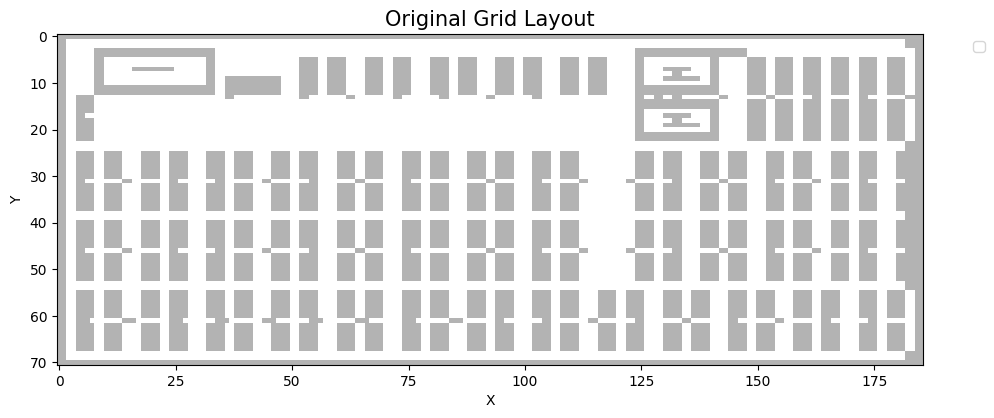


==================== TESTING WITH 10 ROBOTS ====================


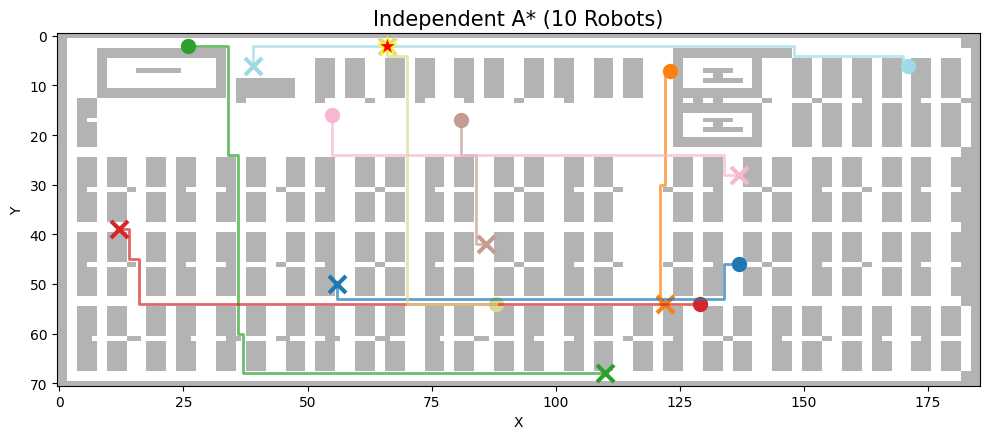

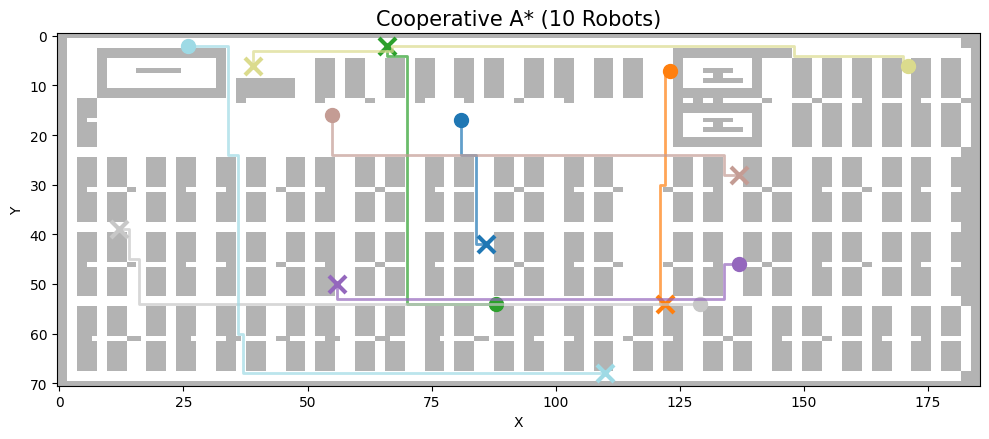

,0,1
Algorithm,Independent,Cooperative
Runtime,135.8311,141.3541
SOC,761,761
Makespan,150,150
Success,0,0
Conflicts,1,0
Memory (MB),54.2344,1.9727
Waiting,0,0
Deadlocks,0,0


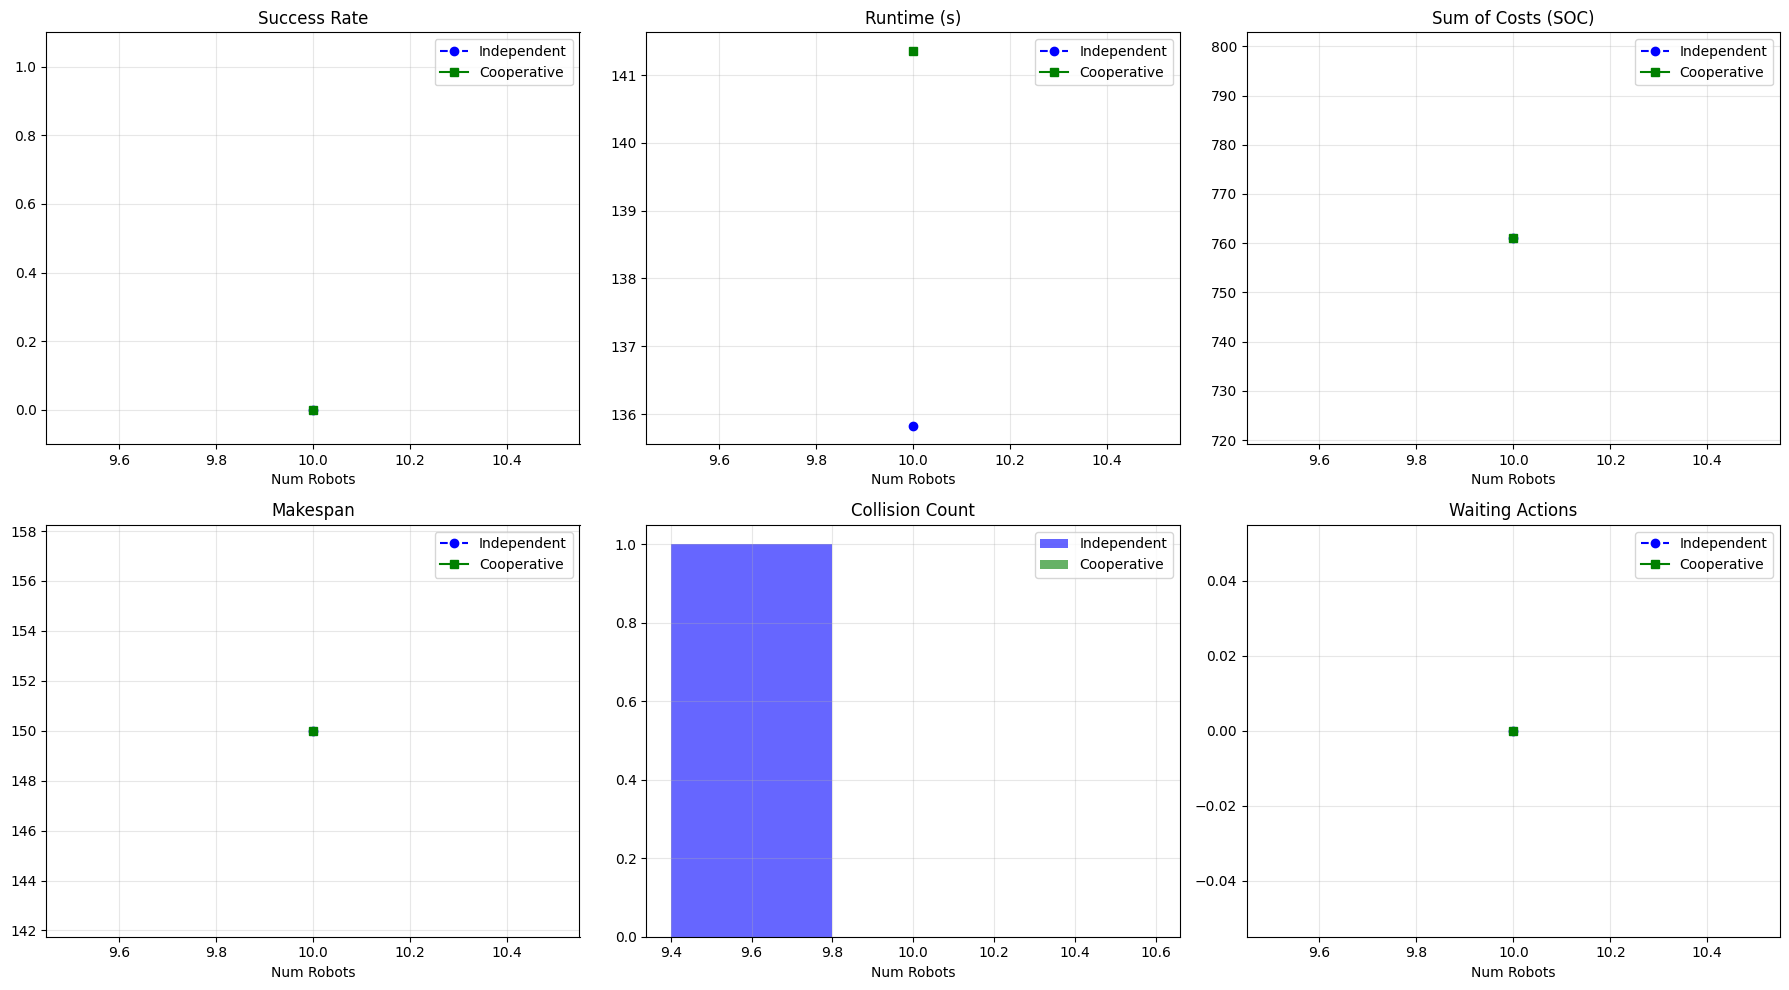

In [13]:
# ========================================
# RUN FINAL BENCHMARK
# ========================================
import os

grid_file = "e:/Intro_to_ai_Project/widjdane_chouali/grid.txt"

if os.path.exists(grid_file):
    print(f"Using map: {grid_file}")
    benchmark = MAPFBenchmark(grid_file)
    # Testing with constant fleet size of 10 agents by default
    results = benchmark.run_full_comparison(fleet_sizes=[10])
else:
    print(f"Could not find {grid_file}. Please check map paths.")